# Sales Prediction Using Python

**Objective:** Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper).

**Author:** Vivek Raj Jha
**Track:** Data Science — Oasis Infobyte Summer Internship Program (OIBSIP)
**Task:** Task 5 — Sales Prediction Using Python


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset
The classic **Advertising.csv** dataset — 200 records of advertising spend (in thousands of dollars) across TV, Radio, and Newspaper channels, along with resulting product sales (in thousands of units).

In [2]:
df = pd.read_csv('Advertising.csv', index_col=0)
df.head()


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.describe()


Shape: (200, 4)

Missing values:
 TV           0
radio        0
newspaper    0
sales        0
dtype: int64


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


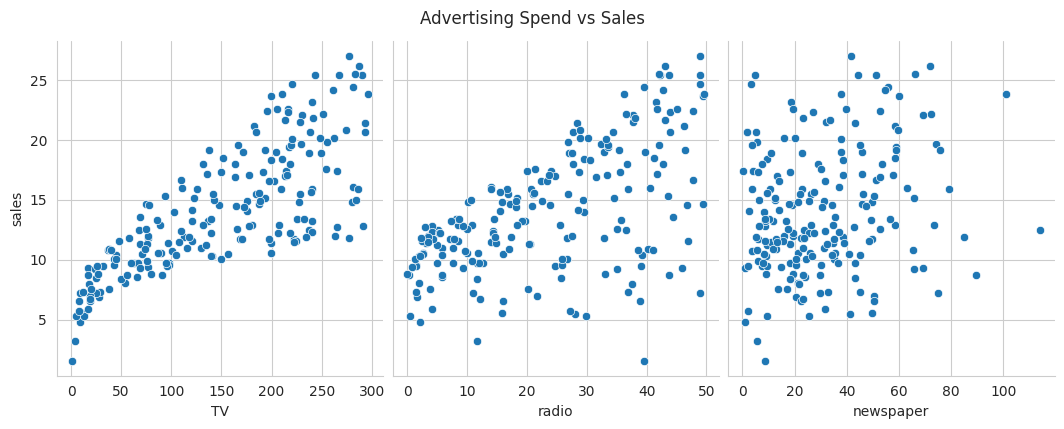

In [4]:
sns.pairplot(df, x_vars=['TV', 'radio', 'newspaper'], y_vars='sales', height=4, aspect=0.9, kind='scatter')
plt.suptitle("Advertising Spend vs Sales", y=1.05)
plt.savefig('pairplot.png', bbox_inches='tight', dpi=120)
plt.show()


## 4. Individual Scatter Plots

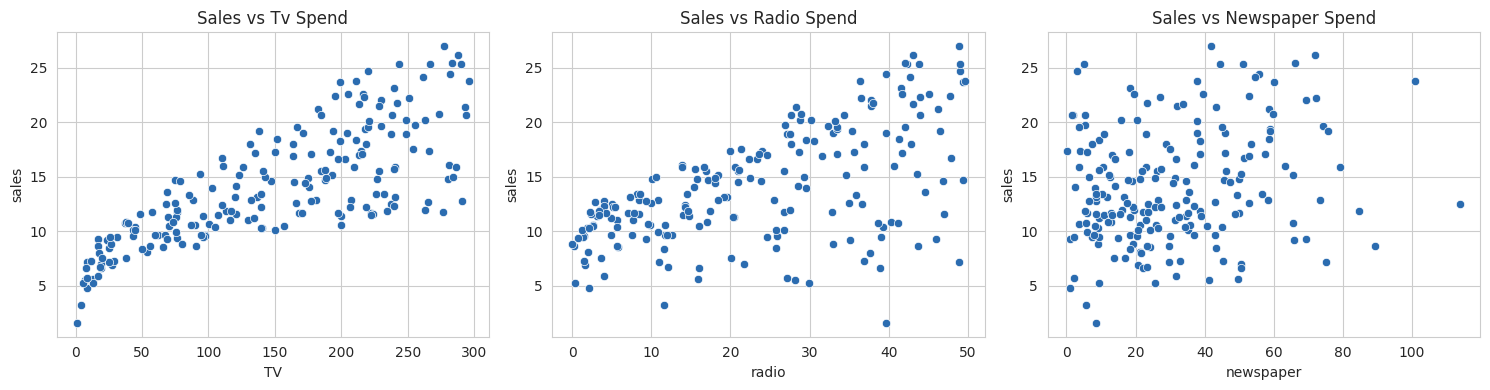

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TV', 'radio', 'newspaper']):
    sns.scatterplot(data=df, x=col, y='sales', ax=ax, color='#2b6cb0')
    ax.set_title(f'Sales vs {col.capitalize()} Spend')
plt.tight_layout()
plt.savefig('scatter_plots.png', bbox_inches='tight', dpi=120)
plt.show()


## 5. Correlation Matrix Heatmap

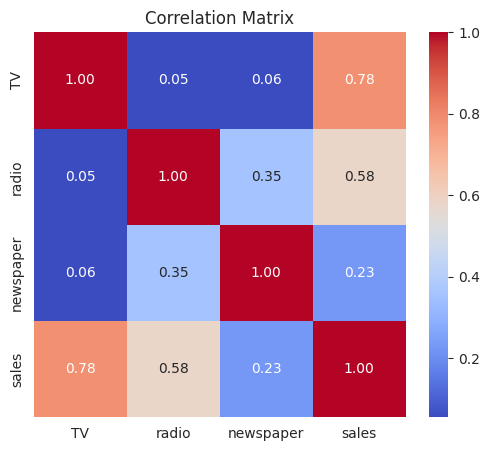

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()


## 6. Train/Test Split

In [7]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 160
Testing samples: 40


## 7. Train Models
A **Linear Regression** model is trained as the baseline, and a **Random Forest Regressor** is trained as an additional, more flexible model for comparison.

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Models trained.")


Models trained.


## 8. Model Evaluation

In [9]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")
    return mae, rmse, r2

results = {}
results['Linear Regression'] = evaluate(y_test, y_pred_lr, "Linear Regression")
results['Random Forest'] = evaluate(y_test, y_pred_rf, "Random Forest Regressor")


--- Linear Regression ---
MAE:  1.4608
RMSE: 1.7816
R2:   0.8994

--- Random Forest Regressor ---
MAE:  0.6287
RMSE: 0.7572
R2:   0.9818



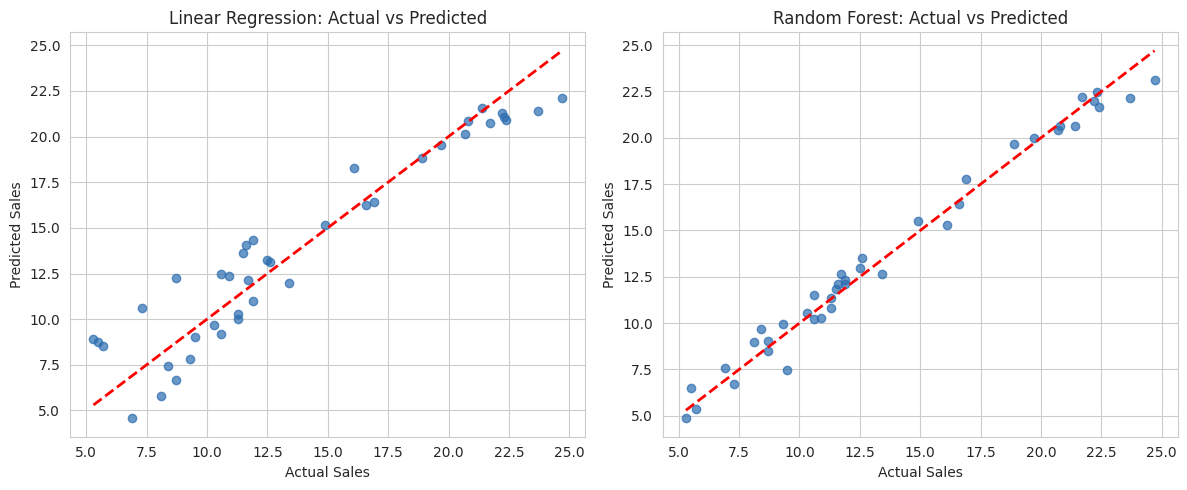

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, preds) in zip(axes, [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf)]):
    ax.scatter(y_test, preds, alpha=0.7, color='#2b6cb0')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')
    ax.set_title(f'{name}: Actual vs Predicted')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight', dpi=120)
plt.show()


## 9. Residual Plot (Best Model)

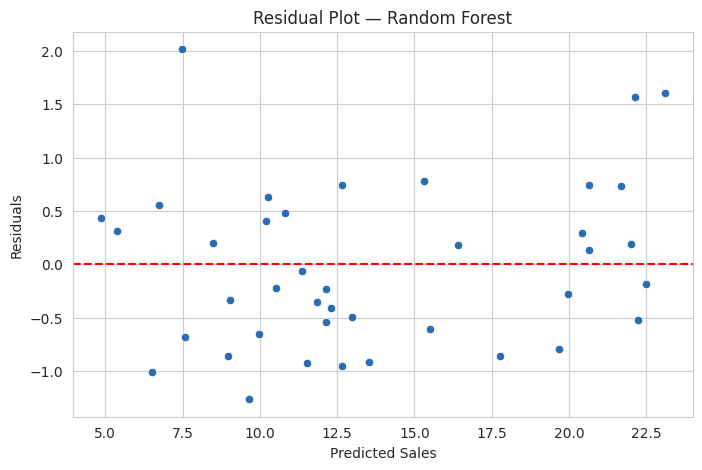

Best model based on R2 score: Random Forest (R2 = 0.9818)


In [11]:
best_name = max(results, key=lambda k: results[k][2])
best_preds = y_pred_lr if best_name == 'Linear Regression' else y_pred_rf
residuals = y_test - best_preds

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_preds, y=residuals, color='#2b6cb0')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title(f'Residual Plot — {best_name}')
plt.savefig('residual_plot.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"Best model based on R2 score: {best_name} (R2 = {results[best_name][2]:.4f})")


## 10. Interpretation — Which Channel Has the Highest Impact?

In [12]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)
print("Linear Regression Coefficients:")
print(coef_df)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nRandom Forest Feature Importances:")
print(importance_df)


Linear Regression Coefficients:
     Feature  Coefficient
1      radio     0.189195
0         TV     0.044730
2  newspaper     0.002761

Random Forest Feature Importances:
     Feature  Importance
0         TV    0.624727
1      radio    0.362119
2  newspaper    0.013153


**Interpretation:** Based on both the Linear Regression coefficients and the Random Forest feature importances, **TV advertising spend has by far the strongest impact on sales**, followed by **Radio**. **Newspaper spend shows a much weaker (and sometimes negligible) relationship with sales**, suggesting that newspaper advertising budget could potentially be reduced or reallocated toward TV and Radio for better returns.

## 11. Conclusion

- The dataset shows a strong linear relationship between TV/Radio advertising spend and sales.
- Both Linear Regression and Random Forest models achieve high R² scores, confirming advertising spend is a strong predictor of sales.
- TV spend is the most influential factor, followed by Radio; Newspaper spend has minimal impact.
- This notebook fulfils the OIBSIP Data Science Task 5 requirements: EDA, scatter plots, correlation heatmap, train/test split, baseline + additional regression model, evaluation metrics (MAE, RMSE, R²), residual plot, and channel-impact interpretation.
